<a href="https://colab.research.google.com/github/Lucas-Rattighieri/falqon-portfolio-optimization/blob/main/Plots.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
#@title Mount Google Drive

from google.colab import drive

drive.mount("/content/drive")
# BASE_PATH = "/content/drive/MyDrive/Colab Notebooks/Mestrado/Artigos/Artigo - Portifólio" # Drive Pedro
BASE_PATH = "/content/drive/MyDrive/codigos/Computação Quântica/Artigo - Portifólio" # Drive Lucas

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/tmp/ipykernel_6738/1808063638.py:195: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


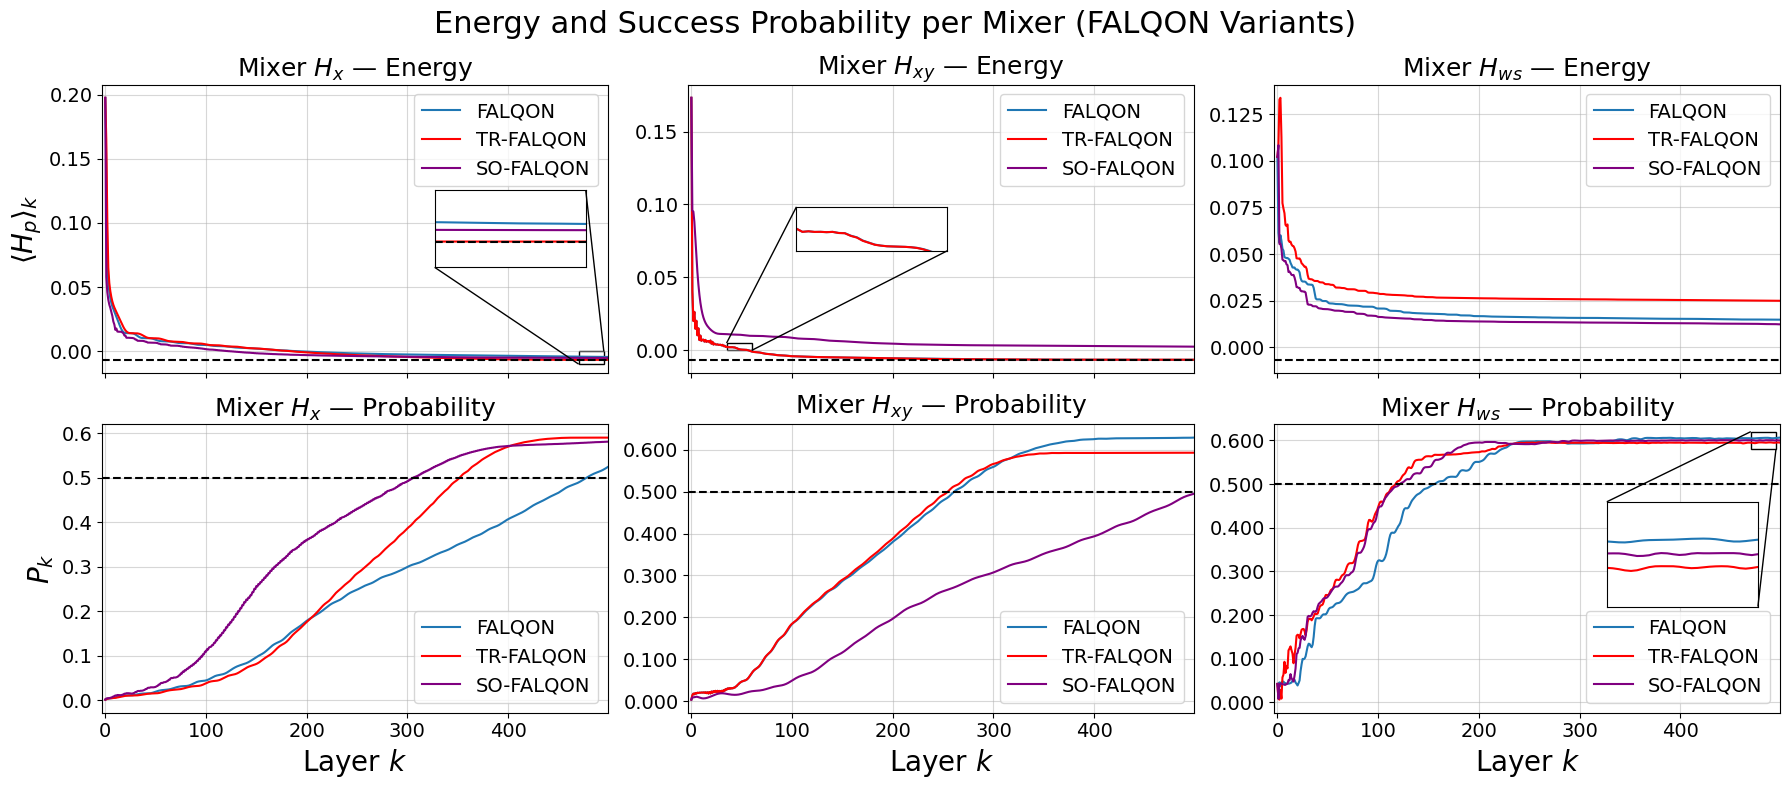

In [62]:
#@title Energy & Probability — 3 Mixers (10 assets, CSV)

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FormatStrFormatter
from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes, mark_inset

# ======================================================
# Load CSV (wide format)
# ======================================================
df_n10 = pd.read_csv(
    f"{BASE_PATH}/energy_probability_3_mixers_10_assets.csv"
)

layers = len(df_n10)

emin = df_n10[
    [
        "E_falqon_x","E_tr_x","E_so_x",
        "E_falqon_xy","E_tr_xy","E_so_xy",
        "E_falqon_warm","E_tr_warm","E_so_warm",
    ]
].min().min()

# ======================================================
# Style parameters (fixed)
# ======================================================
TITLE_SIZE    = 18
SUPTITLE_SIZE = 22
XLABEL_SIZE   = 20
YLABEL_SIZE   = 20
LEGEND_SIZE   = 14
TICK_SIZE     = 14

# Colors
c_falqon = "C0"
c_tr     = "red"
c_so     = "purple"

# ======================================================
# Plot configuration
# ======================================================
fig, axs = plt.subplots(2, 3, figsize=(18, 8), sharex=True)

def plot_mixer(axE, axP, mixer_key, title_energy, title_prob,
               show_ylabel=False, format_prob_3dec=False, legend=True):

    # ---------------- Energy ----------------
    if axE is not None:
        axE.plot(df_n10[f"E_falqon_{mixer_key}"], label="FALQON", color=c_falqon)
        axE.plot(df_n10[f"E_tr_{mixer_key}"],     label="TR-FALQON",     color=c_tr)
        axE.plot(df_n10[f"E_so_{mixer_key}"],     label="SO-FALQON",     color=c_so)
        axE.axhline(float(emin), ls="--", color="black")
        axE.set_title(title_energy, fontsize=TITLE_SIZE)

        if show_ylabel:
            axE.set_ylabel(r"$\langle H_p \rangle_k$", fontsize=YLABEL_SIZE)
        if legend:
            axE.legend(fontsize=LEGEND_SIZE)
        axE.grid(alpha=0.5)
        axE.tick_params(axis="both", labelsize=TICK_SIZE)

    # ---------------- Probability ----------------
    if axP is not None:
        axP.plot(df_n10[f"P_falqon_{mixer_key}"], label="FALQON", color=c_falqon)
        axP.plot(df_n10[f"P_tr_{mixer_key}"],     label="TR-FALQON",     color=c_tr)
        axP.plot(df_n10[f"P_so_{mixer_key}"],     label="SO-FALQON",     color=c_so)
        axP.axhline(0.5, ls="--", color="black")  # Pk = 0.5

        axP.set_title(title_prob, fontsize=TITLE_SIZE)
        axP.set_xlabel(r"Layer $k$", fontsize=XLABEL_SIZE)

        if show_ylabel:
            axP.set_ylabel(r"$P_k$", fontsize=YLABEL_SIZE)

        if format_prob_3dec:
            axP.yaxis.set_major_formatter(FormatStrFormatter("%.3f"))
        if legend:
            axP.legend(fontsize=LEGEND_SIZE)
        axP.grid(alpha=0.5)
        axP.tick_params(axis="both", labelsize=TICK_SIZE)

# ======================================================
# Mixer Hx
# ======================================================

plot_mixer(
    axs[0, 0], axs[1, 0],
    mixer_key="x",
    title_energy=r"Mixer $H_x$ — Energy",
    title_prob=r"Mixer $H_x$ — Probability",
    show_ylabel=True,
    format_prob_3dec=False
)

# Zoom box
axins = zoomed_inset_axes(axs[0,0], zoom=6, loc='center right', bbox_to_anchor=(0.97, 0.5), bbox_transform=axs[0,0].transAxes)
plot_mixer(
    axins, None,
    mixer_key="x",
    title_energy=r"",
    title_prob=r"",
    show_ylabel=False,
    format_prob_3dec=False,
    legend=False
)
axins.set_xlim(470, 495)
axins.set_ylim(-0.01, 0.0)
# axins.get_legend().remove()
axins.set_title("")
axins.set_yticks([])
axins.set_xticks([])
mark_inset(axs[0,0], axins, loc1=3, loc2=1)


# ======================================================
# Mixer Hxy
# ======================================================
plot_mixer(
    axs[0, 1], axs[1, 1],
    mixer_key="xy",
    title_energy=r"Mixer $H_{xy}$ — Energy",
    title_prob=r"Mixer $H_{xy}$ — Probability",
    show_ylabel=False,
    format_prob_3dec=True
)


# Zoom box
axins = zoomed_inset_axes(axs[0,1], zoom=6, loc='center left', bbox_to_anchor=(0.2, 0.5), bbox_transform=axs[0,1].transAxes)
plot_mixer(
    axins, None,
    mixer_key="xy",
    title_energy=r"",
    title_prob=r"",
    show_ylabel=False,
    format_prob_3dec=False,
    legend=False
)
axins.set_xlim(35, 60)
axins.set_ylim(0.0, 0.005)
# axins.get_legend().remove()
axins.set_title("")
axins.set_yticks([])
axins.set_xticks([])
mark_inset(axs[0,1], axins, loc1=2, loc2=4)


# ======================================================
# Mixer Hws
# ======================================================
plot_mixer(
    axs[0, 2], axs[1, 2],
    mixer_key="warm",
    title_energy=r"Mixer $H_{ws}$ — Energy",
    title_prob=r"Mixer $H_{ws}$ — Probability",
    show_ylabel=False,
    format_prob_3dec=True
)


# Zoom box
axins = zoomed_inset_axes(axs[1,2], zoom=6, loc='center right', bbox_to_anchor=(0.97, 0.55), bbox_transform=axs[1,2].transAxes)
plot_mixer(
    None, axins,
    mixer_key="warm",
    title_energy=r"",
    title_prob=r"",
    show_ylabel=False,
    format_prob_3dec=False,
    legend=False
)
axins.set_xlim(470, 495)
axins.set_ylim(0.58, 0.62)
# axins.get_legend().remove()
axins.set_title("")
axins.set_xlabel("")
axins.set_yticks([])
axins.set_xticks([])
mark_inset(axs[1,2], axins, loc1=2, loc2=4)

# ======================================================
# Axes limits and global title
# ======================================================
for i in range(2):
    for j in range(3):
        axs[i, j].set_xlim(-3, layers - 1)

fig.suptitle(
    "Energy and Success Probability per Mixer (FALQON Variants)",
    fontsize=SUPTITLE_SIZE
)

plt.tight_layout()




plt.savefig("energy_probability_3_mixers_10_assets.pdf", bbox_inches="tight")

plt.show()


/tmp/ipykernel_6738/2307049047.py:195: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


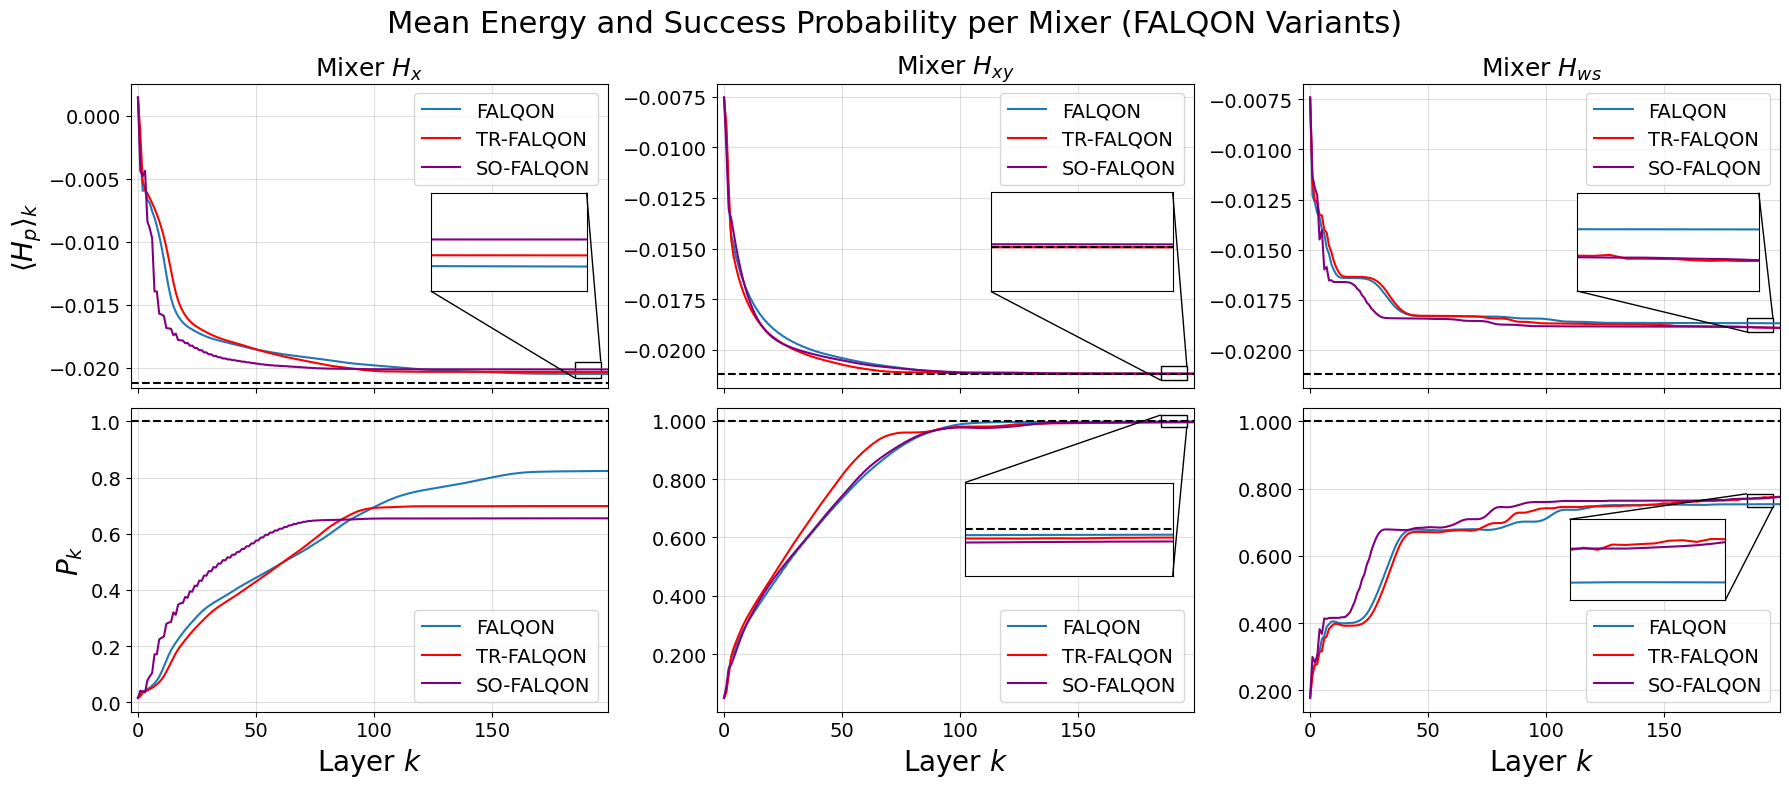

In [138]:
#@title Mean Energy and Probability — CSV (Wide Format)

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter

# ======================================================
# Load CSV
# ======================================================
df_n6 = pd.read_csv(
    f"{BASE_PATH}/mean_energy_probability_mixers.csv"
)

layers = len(df_n6)
emin   = df_n6[
    [
        "E_falqon_x","E_tr_x","E_so_x",
        "E_falqon_xy","E_tr_xy","E_so_xy",
        "E_falqon_warm","E_tr_warm","E_so_warm",
    ]
].min().min()

# ======================================================
# Plot configuration
# ======================================================
fig, axs = plt.subplots(2, 3, figsize=(18, 8), sharex=True)

TITLE_SIZE    = 18
SUPTITLE_SIZE = 22
XLABEL_SIZE   = 20
YLABEL_SIZE   = 20
LEGEND_SIZE   = 14
TICK_SIZE     = 14

def plot_mixer_column(axE, axP, mixer_key, title, show_ylabel=False, format_prob_3dec=False, legend=True):

    if axE is not None:
        # ------------------ Energy ------------------
        axE.plot(df_n6[f"E_falqon_{mixer_key}"], label="FALQON",    color="C0")
        axE.plot(df_n6[f"E_tr_{mixer_key}"],     label="TR-FALQON", color="red")
        axE.plot(df_n6[f"E_so_{mixer_key}"],     label="SO-FALQON", color="purple")
        axE.axhline(float(emin), ls="--", c="k")
        axE.set_title(title, fontsize=TITLE_SIZE)

        if show_ylabel:
            axE.set_ylabel(r"$\langle H_p \rangle_k$", fontsize=YLABEL_SIZE)
        else:
            axE.set_ylabel("")

        if legend:
            axE.legend(fontsize=LEGEND_SIZE)
        axE.grid(alpha=0.4)
        axE.tick_params(axis="both", labelsize=TICK_SIZE)

    if axP is not None:
        # ---------------- Probability ----------------
        axP.plot(df_n6[f"P_falqon_{mixer_key}"], label="FALQON",    color="C0")
        axP.plot(df_n6[f"P_tr_{mixer_key}"],     label="TR-FALQON", color="red")
        axP.plot(df_n6[f"P_so_{mixer_key}"],     label="SO-FALQON", color="purple")
        axP.axhline(1.0, ls="--", c="k")  # Pk = 1 reference

        if show_ylabel:
            axP.set_ylabel(r"$P_k$", fontsize=YLABEL_SIZE)
        else:
            axP.set_ylabel("")

        if format_prob_3dec:
            axP.yaxis.set_major_formatter(FormatStrFormatter("%.3f"))

        axP.set_xlabel("Layer $k$", fontsize=XLABEL_SIZE)
        if legend:
            axP.legend(fontsize=LEGEND_SIZE)
        axP.grid(alpha=0.4)
        axP.tick_params(axis="both", labelsize=TICK_SIZE)

# ======================================================
# Mixer Hx (LEFT — with labels)
# ======================================================
plot_mixer_column(
    axs[0, 0], axs[1, 0],
    mixer_key="x",
    title=r"Mixer $H_x$",
    show_ylabel=True,
    format_prob_3dec=False
)

# Zoom box
axins = zoomed_inset_axes(axs[0,0], zoom=6, loc='center right', bbox_to_anchor=(0.97, 0.48), bbox_transform=axs[0,0].transAxes)
plot_mixer_column(
    axins, None,
    mixer_key="x",
    title=r"",
    show_ylabel=False,
    format_prob_3dec=False,
    legend=False
)
axins.set_xlim(185, 196)
axins.set_ylim(-0.0208, -0.0195)
# axins.get_legend().remove()
axins.set_title("")
axins.set_yticks([])
axins.set_xticks([])
mark_inset(axs[0,0], axins, loc1=3, loc2=1)

# ======================================================
# Mixer Hxy (3 decimals on probability axis)
# ======================================================
plot_mixer_column(
    axs[0, 1], axs[1, 1],
    mixer_key="xy",
    title=r"Mixer $H_{xy}$",
    show_ylabel=False,
    format_prob_3dec=True
)


# Zoom box
axins1 = zoomed_inset_axes(axs[0,1], zoom=7, loc='center right', bbox_to_anchor=(0.97, 0.48), bbox_transform=axs[0,1].transAxes)
axins2 = zoomed_inset_axes(axs[1,1], zoom=8, loc='center right', bbox_to_anchor=(0.97, 0.6), bbox_transform=axs[1,1].transAxes)
plot_mixer_column(
    axins1, axins2,
    mixer_key="xy",
    title=r"",
    show_ylabel=False,
    format_prob_3dec=False,
    legend=False
)

axins1.set_xlim(185, 196)
axins1.set_ylim(-0.0215, -0.0208)
# axins.get_legend().remove()
axins1.set_title("")
axins1.set_yticks([])
axins1.set_xticks([])
mark_inset(axs[0,1], axins1, loc1=3, loc2=1)

axins2.set_xlim(185, 196)
axins2.set_ylim(0.98, 1.02)
# axins.get_legend().remove()
axins2.set_title("")
axins2.set_xlabel("")
axins2.set_yticks([])
axins2.set_xticks([])
mark_inset(axs[1,1], axins2, loc1=2, loc2=4)

# ======================================================
# Mixer Hws (3 decimals on probability axis)
# ======================================================
plot_mixer_column(
    axs[0, 2], axs[1, 2],
    mixer_key="warm",
    title=r"Mixer $H_{ws}$",
    show_ylabel=False,
    format_prob_3dec=True
)

# Zoom box
axins1 = zoomed_inset_axes(axs[0,2], zoom=7, loc='center right', bbox_to_anchor=(0.97, 0.48), bbox_transform=axs[0,2].transAxes)
axins2 = zoomed_inset_axes(axs[1,2], zoom=6, loc='center right', bbox_to_anchor=(0.9, 0.5), bbox_transform=axs[1,2].transAxes)
plot_mixer_column(
    axins1, axins2,
    mixer_key="warm",
    title=r"",
    show_ylabel=False,
    format_prob_3dec=False,
    legend=False
)

axins1.set_xlim(185, 196)
axins1.set_ylim(-0.0191, -0.0184)
# axins.get_legend().remove()
axins1.set_title("")
axins1.set_yticks([])
axins1.set_xticks([])
mark_inset(axs[0,2], axins1, loc1=3, loc2=1)

axins2.set_xlim(185, 196)
axins2.set_ylim(0.745, 0.785)
# axins.get_legend().remove()
axins2.set_title("")
axins2.set_xlabel("")
axins2.set_yticks([])
axins2.set_xticks([])
mark_inset(axs[1,2], axins2, loc1=4, loc2=2)

for i in range(2):
    for j in range(3):
        axs[i, j].set_xlim(-3, layers - 1)

fig.suptitle(
    "Mean Energy and Success Probability per Mixer (FALQON Variants)",
    fontsize=SUPTITLE_SIZE
)

plt.tight_layout()

plt.savefig("mean_energy_probability_mixers.pdf", bbox_inches="tight")

plt.show()


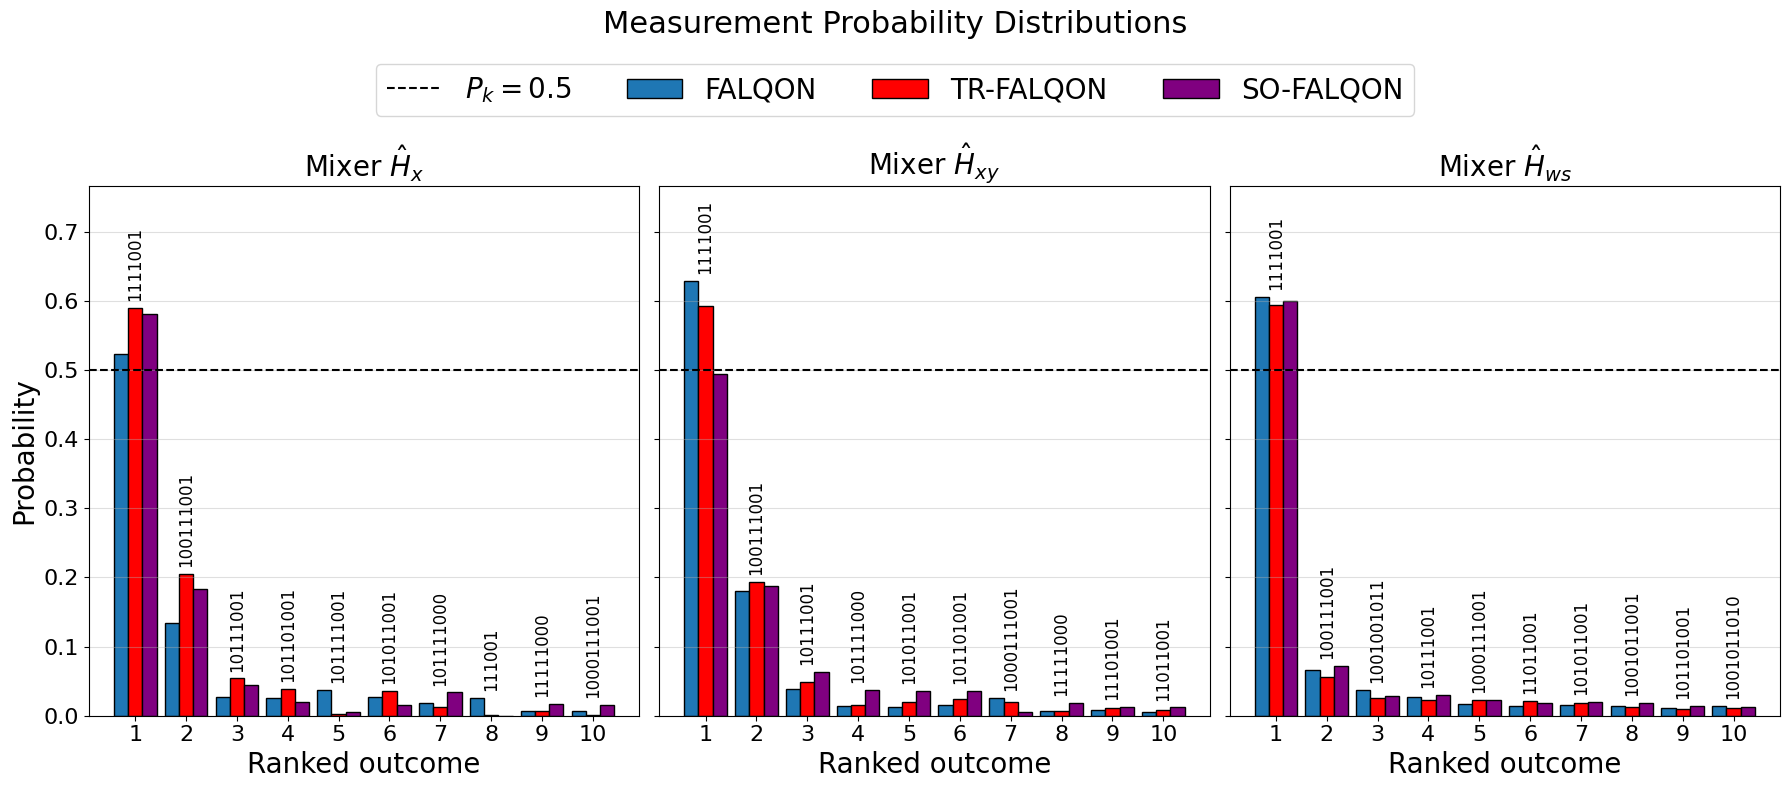

In [ ]:
#@title Plot from CSV — Three Bars per Outcome

# ======================================================
# Read CSV
# ======================================================
comparison_plot_df = pd.read_csv(
    f"{BASE_PATH}/measurement_probability_grouped_bars_ranks.csv"
)

ALGORITHMS = [
    "FALQON",
    "TR-FALQON",
    "SO-FALQON"
]

MIXERS = [
    ("Hx", r"Mixer $\hat H_x$"),
    ("Hxy", r"Mixer $\hat H_{xy}$"),
    ("Hws", r"Mixer $\hat H_{ws}$")
]

ALGORITHM_COLORS = {
    "FALQON": "C0",
    "TR-FALQON": "red",
    "SO-FALQON": "purple"
}

# ======================================================
# Separate data by mixer
# ======================================================
comparison_data = {
    mixer_key: (
        comparison_plot_df.loc[
            comparison_plot_df["mixer"] == mixer_key
        ]
        .sort_values("rank")
        .reset_index(drop=True)
    )
    for mixer_key, _ in MIXERS
}

# ======================================================
# Plot configuration
# ======================================================
fig, axs = plt.subplots(
    1,
    3,
    figsize=(18, 8),
    sharey=True
)

TITLE_SIZE    = 20
SUPTITLE_SIZE = 22
XLABEL_SIZE   = 20
YLABEL_SIZE   = 20
LEGEND_SIZE   = 20
TICK_SIZE     = 16

bar_width = 0.28

bar_offsets = {
    "FALQON": -bar_width,
    "TR-FALQON": 0.0,
    "SO-FALQON": bar_width
}

global_maximum = max(
    dataframe[ALGORITHMS]
    .to_numpy()
    .max()
    for dataframe in comparison_data.values()
)

upper_limit = min(
    1.05,
    max(
        0.57,
        global_maximum * 1.22
    )
)

# ======================================================
# Generate panels
# ======================================================
for column, (
    mixer_key,
    mixer_title
) in enumerate(MIXERS):

    ax = axs[column]
    plot_df = comparison_data[mixer_key]

    ranks = plot_df[
        "rank"
    ].to_numpy()

    # Three bars per rank
    for algorithm in ALGORITHMS:

        ax.bar(
            ranks + bar_offsets[algorithm],
            plot_df[algorithm],
            width=bar_width,
            color=ALGORITHM_COLORS[algorithm],
            edgecolor="black",
            label=algorithm
        )

    # Visibility threshold
    ax.axhline(
        0.5,
        linestyle="--",
        color="black",
        label=r"$P_k=0.5$"
    )

    ax.set_title(
        mixer_title,
        fontsize=TITLE_SIZE
    )

    ax.set_xlabel(
        "Ranked outcome",
        fontsize=XLABEL_SIZE
    )

    if column == 0:
        ax.set_ylabel(
            "Probability",
            fontsize=YLABEL_SIZE
        )

    ax.set_xticks(ranks)
    ax.set_xticklabels(
        ranks.astype(int)
    )

    ax.set_ylim(
        0,
        upper_limit
    )

    ax.tick_params(
        axis="both",
        labelsize=TICK_SIZE
    )

    ax.grid(
        axis="y",
        alpha=0.4
    )

    # P_k above rank 1 and bitstrings above ranks 2–10
    for _, row in plot_df.iterrows():

        rank = row["rank"]

        group_max = max(
            row["FALQON"],
            row["TR-FALQON"],
            row["SO-FALQON"]
        )

        ax.text(
            rank,
            group_max + 0.01,
            row["label_above"],
            ha="center",
            va="bottom",
            rotation=90,
            fontsize=12
        )

# ======================================================
# Global title and legend
# ======================================================
fig.suptitle(
    "Measurement Probability Distributions",
    fontsize=SUPTITLE_SIZE
)

handles, labels = (
    axs[0].get_legend_handles_labels()
)

unique_legend = dict(
    zip(labels, handles)
)

fig.legend(
    unique_legend.values(),
    unique_legend.keys(),
    loc="upper center",
    bbox_to_anchor=(0.5, 0.93),
    ncol=4,
    fontsize=LEGEND_SIZE
)

plt.tight_layout(
    rect=[0, 0, 1, 0.89]
)

plt.savefig(
    "measurement_probability_grouped_bars.pdf",
    bbox_inches="tight"
)

plt.show()

In [ ]:
comparison_plot_df

,rank,label_above,FALQON,TR-FALQON,SO-FALQON,mixer
0,1,$P_k$,0.524016,0.590000,0.580852,Hx
1,2,0100111001,0.134202,0.204491,0.183665,Hx
2,3,0010111001,0.026799,0.053896,0.045034,Hx
3,4,0101101001,0.025953,0.039118,0.020069,Hx
4,5,0101111001,0.036862,0.002209,0.005033,Hx
5,6,0101011001,0.027209,0.035932,0.015601,Hx
6,7,0101111000,0.018976,0.012450,0.033626,Hx
7,8,0000111001,0.025169,0.000742,0.000192,Hx
8,9,0011111000,0.006347,0.006270,0.016366,Hx
9,10,1000111001,0.006495,0.000627,0.015592,Hx
